### 0. Interpreter와 Notebook Kernel이 다르면 터미널에서는 설치된 패키지가 Notebook에서 보이지 않는 문제가 생길 수 있습니다.

실행 코드

In [226]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Current working directory:", Path.cwd())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python executable: c:\dev\kant-axagent-study\.venv\Scripts\python.exe
Python version: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Current working directory: c:\dev\kant-axagent-study\llm-data-analysis-course\notebooks
pandas: 3.0.5
numpy: 2.5.2


기본 라이브러리 실행 오류 여부 확인

현재 Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]

현재 Notebook Kernel:  c:\dev\kant-axagent-study\.venv\Scripts\python.exe

현재 작업 폴더:  c:\dev\kant-axagent-study\llm-data-analysis-course\notebooks

확인한 패키지: panddas, numpy

환경에서 추가로 확인할 점: 

### STEP 02. Titanic 데이터 확보와 로딩
02_1 프로잭트 루트 찾기

In [227]:
from pathlib import Path

def get_project_root(start_path: Path | None = None) -> Path:
    """현재 위치에서 상위 폴더를 탐색해 data 폴더가 있는 프로젝트 루트를 찾는다."""
    current = (start_path or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "data").is_dir():
            return path
    raise FileNotFoundError("data 폴더가 있는 프로젝트 루트를 찾을 수 없습니다.")

project_root = get_project_root()
data_path = project_root / "data" / "titanic" / "train.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Titanic 데이터가 없습니다: {data_path}\n"
        "저장소 루트에서 python scripts/prepare_titanic_data.py 를 먼저 실행하세요."
    )
print("project_root :", project_root)
print("data_path :", data_path)

project_root : C:\dev\kant-axagent-study\llm-data-analysis-course
data_path : C:\dev\kant-axagent-study\llm-data-analysis-course\data\titanic\train.csv


프로젝트 root 및 데이터 파일 경로 가져오기 성공

02_2 데이터 로딩

In [228]:

import pandas as pd

df = pd.read_csv(data_path)

print("data path:", data_path)
print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()


data path: C:\dev\kant-axagent-study\llm-data-analysis-course\data\titanic\train.csv
shape: (891, 12)
columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


df = 원본 기준 데이터
df 기본 관찰 결과
...
...

### STEP 03. 데이터 구조와 품질의 첫인상 확인
03_1 크기와 앞부분 확인

In [229]:
print("shape:", df.shape)

df.head()

shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


03_2. dtype과 기본 구조 확인

In [230]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


02_3. 결측치 요약

In [231]:

missing_count = df.isna().sum()
missing_rate = (df.isna().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_rate_pct": missing_rate,
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_rate_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


02_4. 중복과 기초 통계

In [232]:

print("duplicate rows:", df.duplicated().sum())

df.describe(include="all")

duplicate rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [233]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

★ 개인 판단 지점 1

학생이 추가로 확인하고 싶은 데이터 품질 항목을 하나 선택합니다.

예:
- PassengerId 중복 여부

- Age 범위

- Fare 이상치

- 각 범주형 컬럼의 unique 개수

- Sex / Embarked / Pclass의 값 분포

### STEP 04. 분석 문제와 Target 정의

In [234]:
print("Survived missing:", df["Survived"].isna().sum())
print("Survived unique:", sorted(df["Survived"].dropna().unique()))
print("\nClass count")
print(df["Survived"].value_counts().sort_index())
print("\nClass ratio")
print(df["Survived"].value_counts(normalize=True).sort_index())

Survived missing: 0
Survived unique: [np.int64(0), np.int64(1)]

Class count
Survived
0    549
1    342
Name: count, dtype: int64

Class ratio
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Survived가 0과 1 두 범주이므로 이번 문제는 기본적으로 이진 분류(Binary Classification) 문제입니다.

04_02 Feature와 Target

Feature = 예측에 사용할 입력 정보
Target  = 맞히고 싶은 정답

예를 들어 Sex, Pclass, Age, Fare 등은 Feature 후보가 될 수 있고 Survived는 Target입니다.

step 05. 결측치 처리

In [235]:
df_work = df.copy()

객체 역할은 다음처럼 구분합니다.

df      = 원본 기준 데이터
df_work = STEP 05~10 탐색 / EDA 작업본

결측치 다시 확인

In [236]:

missing_summary = pd.DataFrame({
    "count": df_work.isna().sum(),
    "rate_pct": (df_work.isna().mean() * 100).round(2),
}).sort_values("count", ascending=False)

missing_summary

,count,rate_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


탐색용 기본안

이번 Part의 기본 실행안에서는 EDA를 계속 진행하기 위해 다음 정도의 탐색용 처리를 사용할 수 있습니다.

In [237]:
age_median_for_eda = df_work["Age"].median()
embarked_mode_for_eda = df_work["Embarked"].mode(dropna=True).iloc[0]
df_work["Age"] = df_work["Age"].fillna(age_median_for_eda)
df_work["Embarked"] = df_work["Embarked"].fillna(embarked_mode_for_eda)

print("EDA Age median:", age_median_for_eda)
print("EDA Embarked mode:", embarked_mode_for_eda)
display(df_work[["Age", "Embarked", "Cabin"]].isna().sum().to_frame("missing"))

EDA Age median: 28.0
EDA Embarked mode: S


,missing
Age,0
Embarked,0
Cabin,687


Cabin은 결측치가 매우 많지만 바로 삭제하지 않습니다.

Cabin

→ Deck 같은 파생 Feature 후보가 될 수 있음
→ CabinKnown 같은 정보로 변환할 수도 있음
→ 우선 보존


In [238]:

df_work[["Age", "Embarked", "Cabin"]].isna().sum()

Age           0
Embarked      0
Cabin       687
dtype: int64

매우 중요한 구분

위 처리는 탐색과 EDA를 위한 처리입니다.

STEP 05 전체 데이터 median / mode
→ 탐색용

최종 모델링 전처리
→ train 데이터에서만 학습

 

나중에 모델을 만들 때는 전체 데이터에서 계산한 중앙값이나 최빈값을 그대로 재사용하지 않습니다.

 

★ 개인 판단 지점 2

 

학생이 Age, Embarked, Cabin 중 최소 하나에 대해 자신의 처리 전략과 이유를 기록합니다.

### STEP 06. 불필요한 컬럼 검토

 

이번 단계에서는 컬럼을 보자마자 삭제하지 않습니다. 각 컬럼의 역할을 다음 네 가지로 판단합니다.


### 핵심 개념

 

KEEP    유지    = 그대로 사용할 후보

EXCLUDE 제외 후보 = 모델 입력에서는 제외할 후보

DERIVE  파생 후보 = 새로운 Feature를 만들 재료

DEFER   보류    = 지금 결정하지 않고 나중에 다시 판단

 

특히 다음 컬럼을 검토합니다.

 

Column

생각할 점

PassengerId

식별자 자체가 예측에 의미가 있는가?

Name

Title 같은 정보를 파생할 수 있는가?

Ticket

그룹 또는 prefix 정보가 있을 수 있는가?

Cabin

Deck 또는 객실 정보 존재 여부를 만들 수 있는가?

 

학생은 다음 표를 직접 채웁니다.

 

Column

Decision

Reason

PassengerId

Name

Ticket

Cabin

 

이번 단계에서는 Name, Ticket, Cabin을 파괴적으로 삭제하지 않습니다.

★ 개인 판단 지점 3

 

최소 한 개 컬럼에 대해 KEEP / EXCLUDE / DERIVE / DEFER 중 하나를 선택하고 이유를 기록합니다.

STEP 07. 범주형 데이터 변환 원리 이해

 

머신러닝 모델은 문자열 범주를 그대로 처리하지 못하는 경우가 많습니다. 아직 모델을 만들지는 않지만 범주형 데이터를 숫자로 표현하는 원리를 먼저 배웁니다.

범주형 값 확인

In [239]:

for col in ["Sex", "Embarked", "Pclass"]:

    print(f"\n[{col}]")

    print(df_work[col].value_counts(dropna=False))



[Sex]
Sex
male      577
female    314
Name: count, dtype: int64

[Embarked]
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

[Pclass]
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


 
Pclass는 숫자로 저장되어 있지만 1등석, 2등석, 3등석이라는 범주 의미로 볼 수도 있습니다.

 

교육용 인코딩 branch

In [240]:
df_encoded = df_work.copy()


df_encoded = df_work.copy()

 

객체 역할은 다음과 같습니다.

 

df_encoded = 인코딩 원리 학습용 임시 데이터

### Mapping 예시

 

Sex처럼 두 값으로 구성된 범주는 단순 mapping을 이해하기 좋습니다.

In [241]:
df_encoded["SexMapped"] = df_encoded["Sex"].map({

    "male": 0,

    "female": 1,

})

df_encoded[["Sex", "SexMapped"]].head()

,Sex,SexMapped
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0


### One-Hot Encoding 예시

 

Embarked처럼 명목형 범주에 임의로 0, 1, 2를 부여하면 존재하지 않는 순서 관계를 모델이 해석할 수 있습니다.

 

교육용으로 pd.get_dummies()를 사용해 원리를 확인합니다.

In [242]:

embarked_dummies = pd.get_dummies(

    df_encoded["Embarked"],

    prefix="Embarked",

    dtype=int,

)

embarked_dummies.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1



중요

df_encoded와 pd.get_dummies() 결과는 인코딩 원리를 배우기 위한 것입니다. 다음 Part의 최종 모델링 입력으로 그대로 사용하지 않습니다. 실제 모델링에서는 train/test를 먼저 나눈 뒤 학습 데이터 기준으로 전처리를 학습합니다

★ 개인 판단 지점 4

 

학생이 다음을 판단합니다.

 

Sex는 mapping이 적절한가?

Embarked는 One-Hot이 적절한가?

Pclass는 숫자형인가, 범주형인가?

 

### STEP 08. 시각화와 기본 패턴 확인

 

이제 그래프를 그립니다. 하지만 가장 먼저 그래프 종류를 고르는 것이 아니라 질문을 먼저 만듭니다.

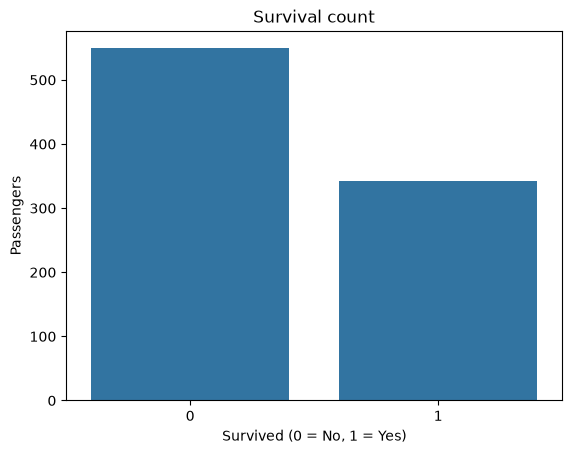

In [243]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_work, x="Survived")

plt.title("Survival count")

plt.xlabel("Survived (0 = No, 1 = Yes)")

plt.ylabel("Passengers")

plt.show()

학생은 그래프를 보고 먼저 보이는 사실만 적습니다.

 

관찰: 0이 1보다 더 많다.

해석: 생존자보다 사망자가 더 많음

추가 확인: 생존자의 구성 궁금

### 질문 2. 성별에 따라 생존율이 다른가?



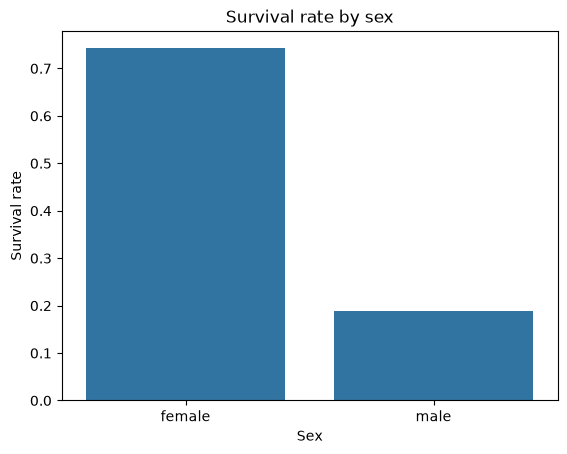

In [244]:
sex_survival = (

    df_work.groupby("Sex", as_index=False)["Survived"]

    .mean()

)

sns.barplot(data=sex_survival, x="Sex", y="Survived")

plt.title("Survival rate by sex")

plt.ylabel("Survival rate")

plt.show()

학생은 그래프를 보고 먼저 보이는 사실만 적습니다.

 

관찰: 생존자 중 여성이 남성보다 더 생존자 수가 더 많음

해석: 생존자 중에는 여성이 많다

추가 확인: 왜 그런지 이유 궁금

여기서 중요한 것은 인과관계를 단정하지 않는 것입니다.

 

X  여성이기 때문에 생존했다.

O  여성 승객 집단에서 더 높은 생존율이 관찰되는지 확인한다.

### 질문 3. 객실 등급에 따라 생존율이 다른가?

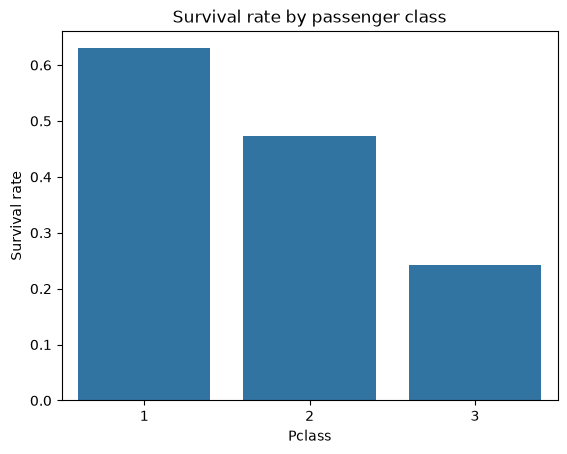

In [245]:

pclass_survival = (

    df_work.groupby("Pclass", as_index=False)["Survived"]

    .mean()

)

sns.barplot(data=pclass_survival, x="Pclass", y="Survived")

plt.title("Survival rate by passenger class")

plt.ylabel("Survival rate")

plt.show()

학생은 그래프를 보고 먼저 보이는 사실만 적습니다.

 

관찰: 1 pclass의 생존자가 다른 class의 생존자 보다 많다.

해석: 1등석의 생존자가 다른 좌석의 생존자 보다 많음

추가 확인: 1등석이 실제 위치 궁금

### 질문 4. 나이와 생존 사이에 어떤 패턴이 보이는가?

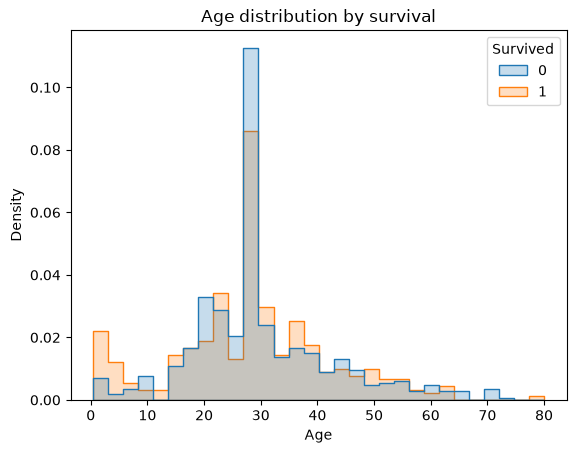

In [246]:
sns.histplot(

    data=df_work,

    x="Age",

    hue="Survived",

    bins=30,

    element="step",

    stat="density",

    common_norm=False,

)

plt.title("Age distribution by survival")

plt.show()

학생은 그래프를 보고 먼저 보이는 사실만 적습니다.

 

관찰: 30대의 생존자와 사망자의 density가 높음

해석: 30대의 생존자와 사망자의 비율 높음, 10세 미만의 아이 들은 생존자 비율 높음, 30대 후반의 생존자 비율 높음

추가 확인: 왜 나이에 따른 이런 그래프가 나왔는지 궁금함

 

Age 그래프를 볼 때 반드시 기억할 점

 

df_work["Age"]에는 STEP 05의 탐색용 중앙값 대체가 반영되어 있습니다.

 

raw df의 Age 분포

≠

결측치가 대체된 df_work의 Age 분포

 

즉 그래프도 전처리 방식의 영향을 받을 수 있습니다.

### 질문 5. Fare와 생존 사이에 어떤 패턴이 보이는가?

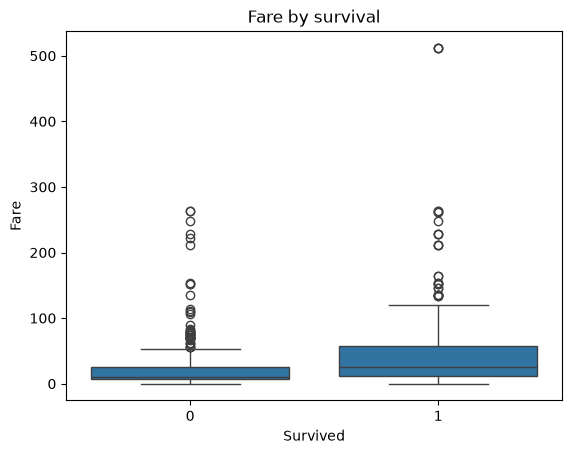

In [247]:

sns.boxplot(data=df_work, x="Survived", y="Fare")

plt.title("Fare by survival")

plt.xlabel("Survived")

plt.ylabel("Fare")

plt.show()

학생은 그래프를 보고 먼저 보이는 사실만 적습니다.

 

관찰: 생존자의 평균 운임이 높음

해석: 1등석 생존자수와 연관하여 생각했을 때 운임이 높은 승객의 생존자가 더 많음

추가 확인: 왜 운임 높은 생존자가 더 많은지 이유 분석하고 싶음

 

Fare는 큰 값이 포함될 수 있으므로 그래프 축과 이상치의 영향을 함께 봅니다.

 

★ 개인 판단 지점 5

 

기본 그래프를 확인한 뒤 학생이 추가 시각화 하나를 직접 선택합니다.


### 질문 6 승선 항구별 생존율

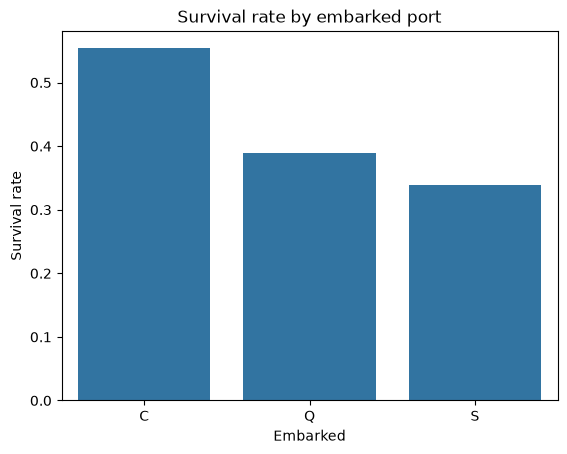

In [248]:
embarked_survival = (
    df_work.groupby("Embarked", as_index=False)["Survived"]
    .mean()
)

sns.barplot(
    data=embarked_survival,
    x="Embarked",
    y="Survived"
)

plt.title("Survival rate by embarked port")
plt.xlabel("Embarked")
plt.ylabel("Survival rate")
plt.show()

학생은 그래프를 보고 먼저 보이는 사실만 적습니다.

C: Cherbourg
Q: Queenstown
S: Southampton

관찰: C 승선지의 생존자 비율이 높음

해석: 다른 항구의 승선자보다 c 항구의 승선자 수가 많음

추가 확인: 실제 사람들이 여기서 많이 타서 그런지, 운임과 연관이 있는지 궁금함

### 7. 형제, 배우자 수에 따른 생존율

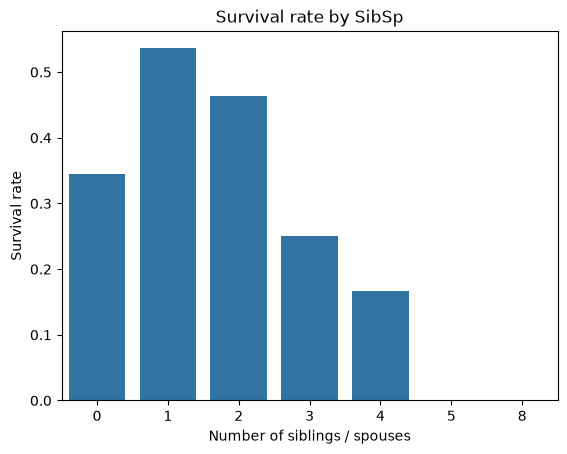

In [249]:
sibsp_survival = (
    df_work.groupby("SibSp", as_index=False)["Survived"]
    .mean()
)

sns.barplot(
    data=sibsp_survival,
    x="SibSp",
    y="Survived"
)

plt.title("Survival rate by SibSp")
plt.xlabel("Number of siblings / spouses")
plt.ylabel("Survival rate")
plt.show()

학생은 그래프를 보고 먼저 보이는 사실만 적습니다.


관찰: 배우자와 형제자매가 있는 사람의 생존율이 높음

해석: 없는 사람보다 배우자 또는 형제 자매가 있는 사람들의 생존율이 높음

추가 확인: 실제로 서로 도와서 더 탈출하기 쉬웠는지 궁금함

### 8. 가족 규모 생존율

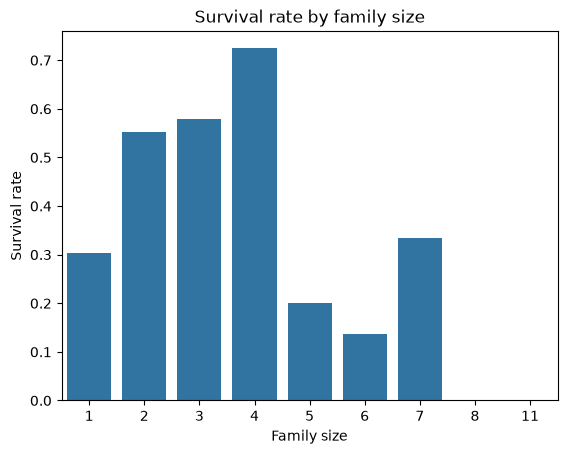

In [250]:
df_work["FamilySize"] = (
    df_work["SibSp"]
    + df_work["Parch"]
    + 1
)

family_survival = (
    df_work.groupby("FamilySize", as_index=False)["Survived"]
    .mean()
)

sns.barplot(
    data=family_survival,
    x="FamilySize",
    y="Survived"
)

plt.title("Survival rate by family size")
plt.xlabel("Family size")
plt.ylabel("Survival rate")
plt.show()

학생은 그래프를 보고 먼저 보이는 사실만 적습니다.


관찰: 가족 규모가 있는 사람의 생존율이 혼자인 사람보다 높음

해석: 특히 4인까지는 가족 규모가 클수록 생존율이 올라감

추가 확인: 실제로 왜 가족규모가 생존율에 영향을 끼쳤는지 궁금함

## STEP 09. 기초 통계와 EDA

### 실행 계획

df_work에서 Sex별, Pclass별, Sex×Pclass별 승객 수와 생존율을 확인한다.

원칙: 비율과 표본 수를 함께 본다. 그룹 차이를 원인으로 단정하지 않는다.

In [251]:
display(df_work.groupby("Sex").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

display(df_work.groupby("Pclass").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

display(df_work.groupby(["Sex", "Pclass"]).agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

,rows,survival_rate
Sex,,
female,314,0.742038
male,577,0.188908


,rows,survival_rate
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


rows  survival_rate
Sex    Pclass                     
female 1         94       0.968085
       2         76       0.921053
       3        144       0.500000
male   1        122       0.368852
       2        108       0.157407
       3        347       0.135447

STEP 08의 Fare boxplot에서 눈으로 본 차이를 숫자(p-value)로 다시 확인합니다. 생존(1)/비생존(0) 두 그룹의 Fare 평균이 실제로 다른지 보는 가장 기초적인 통계검정인 독립표본 t-검정을 사용합니다.

In [252]:

from scipy import stats

survived = df_work.loc[df_work["Survived"] == 1, "Fare"]

not_survived = df_work.loc[df_work["Survived"] == 0, "Fare"]

t_stat, p_value = stats.ttest_ind(survived, not_survived, equal_var=False)

print("survived Fare mean:", round(survived.mean(), 2), " n =", survived.shape[0])

print("not survived Fare mean:", round(not_survived.mean(), 2), " n =", not_survived.shape[0])

print(f"t-statistic: {t_stat:.4f}")

print(f"p-value: {p_value:.3e}")

survived Fare mean: 48.4  n = 342
not survived Fare mean: 22.12  n = 549
t-statistic: 6.8391
p-value: 2.699e-11


직접 실행

 

위 세 표와 t-검정 코드를 실행하고, 각 그룹의 rows(표본 수)와 survival_rate(생존율), 그리고 t-검정의 p-value를 함께 읽습니다. 표본 수가 매우 작은 그룹의 생존율은 신중하게 해석합니다.

 

확인해야 할 실제 출력/결과

 

Sex별 rows/survival_rate
female	314	0.742038
male	577	0.188908

Pclass별 rows/survival_rate
	rows	survival_rate
Pclass		
1	216	0.629630
2	184	0.472826
3	491	0.242363

Sex × Pclass별 rows/survival_rate
		rows	survival_rate
Sex	Pclass		
female	1	94	0.968085
2	76	0.921053
3	144	0.500000
male	1	122	0.368852
2	108	0.157407
3	347	0.135447


생존/비생존 그룹의 Fare 평균, t-statistic, p-value
		rows	survival_rate
Sex	Pclass		
female	1	94	0.968085
2	76	0.921053
3	144	0.500000
male	1	122	0.368852
2	108	0.157407
3	347	0.135447


관찰: 그룹별 생존율에 차이가 나타났다. 생존/비생존 그룹의 Fare 평균도 다르게 나타났고,

     t-검정 결과 p-value가 (실제 실행 결과)로 나타났다.

해석: 해당 변수(들)가 Survived와 관련되어 있을 가능성이 있다.

가설: 다른 변수와 함께 볼 때 패턴이 달라질 수 있다.

한계: p-value가 작다는 것은 "우연이 아닐 가능성"을 보여줄 뿐, Fare가 생존의

     원인이라는 뜻은 아니다.

추가 확인: 필요한 조합만 골라 groupby로 다시 확인한다.

개인 판단 지점

 

★ 개인 판단 지점 6. AI에게 추가 EDA 질문 후보를 요청하고(예: Age와 생존, 가족 규모와 생존, Age 그룹 간 t-검정) 최소 1개를 선택해 실행합니다. 선택 이유와 결과를 기록하고, STEP 10에 전달할 Feature 후보 메모를 남깁니다.

### STEP 10. Feature 설계

 

이번 단계에서 무엇을 배우는가

 

EDA에서 발견한 패턴을 모델이 사용할 수 있는 입력 정보 후보로 바꿉니다. Feature Engineering은 새 컬럼을 많이 만드는 일이 아니라, 재현 가능하고 누수 위험이 없는 입력 정보를 설계하는 일입니다.

 

이전 STEP과 어떻게 연결되는가

 

STEP 08–09에서 df_work로 확인한 관찰이 이번 단계의 Feature 아이디어 재료가 됩니다.

 

핵심 개념

 

Feature는 성격이 다른 두 종류로 나뉩니다.

 

A. 행 단위 결정적 Feature

   한 행의 값과 미리 정한 고정 규칙만으로 계산 가능

   예: FamilySize = SibSp + Parch + 1, IsAlone = FamilySize == 1,

       고정 문자열 규칙의 Title/Deck, 미리 정한 고정 경계의 AgeGroup

   → 같은 규칙을 train/test/새 승객에 동일하게 적용 가능

B. 데이터에서 기준을 학습하는 Feature

   전체 데이터의 분포·빈도·통계값이 있어야 계산 가능

   예: qcut 기반 구간, 빈도 기반 rare category 병합, Ticket 전체 등장 횟수 기반

       TicketGroupSize, 평균/중앙값/분위수 기반 변환

   → train에서만 기준을 학습해야 하며, 이번 기본 실습에서는 무리하게 사용하지 않음

In [253]:
feature_demo = df_work.copy()

feature_demo["FamilySize"] = feature_demo["SibSp"] + feature_demo["Parch"] + 1

feature_demo["IsAlone"] = (feature_demo["FamilySize"] == 1).astype(int)

display(feature_demo[["SibSp", "Parch", "FamilySize", "IsAlone", "Survived"]].head())

,SibSp,Parch,FamilySize,IsAlone,Survived
0,1,0,2,0,0
1,1,0,2,0,1
2,0,0,1,1,1
3,1,0,2,0,1
4,0,0,1,1,0


In [254]:
model_source.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                                Heikkinen, Miss Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

관찰: FamilySize, IsAlone이 규칙대로 생성되었다.

해석: 이 두 Feature는 새 승객에게도 동일한 규칙으로 재현 가능하다.

판단: 이번 기본 실행 Contract에서 FamilySize, IsAlone을 채택한다.

      qcut, 빈도 기반 변환 등 학습형 Feature는 이번 Baseline에서는 보류한다.

 

개인 판단 지점

 

★ 개인 판단 지점 7. 후보를 비교한 뒤 실제로 만들 Feature를 직접 선택하고, STEP 10 → STEP 11 Feature Contract를 작성합니다.

 

### STEP 10 → STEP 11 Feature Contract

- 사용할 결정적 Feature: FamilySize, IsAlone (기본 실행 Contract)

- 보류한 Feature와 이유:

- 학습형/전역 규칙 여부 검토:

- 선택 이유:

## STEP 11. 학습/테스트 데이터 준비

### 실행 계획

1. 원본 df가 보존되어 있는지 확인한다.

2. STEP 10에서 선택한 결정적 Feature와 생성 규칙을 확인한다.

3. build_model_features()로 model_source를 만든다.

4. Target(Survived)과 입력 Feature를 분리해 X, y를 만든다.

5. train_test_split으로 train/test를 먼저 나눈다 (test_size=0.2, random_state=42, stratify=y).

6. shape, Target 비율, 인덱스 중복을 확인한다.

7. 결측치 대체와 One-hot Encoding은 아직 실행하지 않는다.
[출처] AI와 함께 타이타닉 데이터 분석 한 사이클 완주하기|작성자 아토믹데브

### 11-1. 원본 df에서 모델링용 데이터 만들기

In [255]:

model_source = df.copy()

model_source["FamilySize"] = (

    model_source["SibSp"] + model_source["Parch"] + 1

)

model_source["IsAlone"] = (

    model_source["FamilySize"] == 1

).astype(int)

### 11-2. 사용할 Feature 직접 작성

In [256]:

raw_input_columns = [

    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"

]

feature_columns = raw_input_columns + ["FamilySize", "IsAlone"]

numeric_features = [

    "Age", "SibSp", "Parch", "Fare", "FamilySize"

]

categorical_features = [

    "Pclass", "Sex", "Embarked", "IsAlone"

]

### 11-3. X와 y 만들기

In [257]:
X = model_source[feature_columns].copy()

y = model_source["Survived"].astype(int).copy()

### 11-4. Train/Test 분리

In [258]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y,

)

In [259]:
model_source[feature_columns].head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


## STEP 12. 전처리를 하나씩 직접 실행하기

### STEP 12-1. 숫자형 결측치 처리

In [260]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy="median")

X_train_num_imputed = pd.DataFrame(

    numeric_imputer.fit_transform(X_train[numeric_features]),

    columns=numeric_features,

    index=X_train.index,

)

X_test_num_imputed = pd.DataFrame(

    numeric_imputer.transform(X_test[numeric_features]),

    columns=numeric_features,

    index=X_test.index,

)

핵심은 다음입니다.

 

Train → fit_transform()

Test  → transform()

 

즉 중앙값은 Train에서만 배웁니다.

### STEP 12-2. 범주형 결측치 처리

In [261]:

categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_cat_imputed = pd.DataFrame(

    categorical_imputer.fit_transform(X_train[categorical_features]),

    columns=categorical_features,

    index=X_train.index,

)

X_test_cat_imputed = pd.DataFrame(

    categorical_imputer.transform(X_test[categorical_features]),

    columns=categorical_features,

    index=X_test.index,

)

### STEP 12-3. One-Hot Encoding

In [262]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(

    handle_unknown="ignore",

    sparse_output=False,

)

X_train_cat_encoded_array = encoder.fit_transform(X_train_cat_imputed)

X_test_cat_encoded_array = encoder.transform(X_test_cat_imputed)

encoded_feature_names = encoder.get_feature_names_out(categorical_features)

X_train_cat_encoded = pd.DataFrame(

    X_train_cat_encoded_array,

    columns=encoded_feature_names,

    index=X_train.index,

)

X_test_cat_encoded = pd.DataFrame(

    X_test_cat_encoded_array,

    columns=encoded_feature_names,

    index=X_test.index,

)

### STEP 12-4. 정규화와 표준화 구분

 

두 용어를 구분합니다.

 

정규화 Normalization

대표 예: MinMaxScaler

→ 값을 보통 0~1 범위로 맞춤

표준화 Standardization

대표 예: StandardScaler

→ 평균 0, 표준편차 1을 기준으로 맞춤

 

먼저 정규화가 어떤 모습인지 개념 확인용으로 봅니다.

### STEP 12-5. StandardScaler로 실제 표준화

 

이번 모델에서는 숫자형 Feature의 단위와 범위를 맞추기 위해 StandardScaler를 사용합니다.


In [263]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(

    scaler.fit_transform(X_train_num_imputed),

    columns=numeric_features,

    index=X_train.index,

)

X_test_num_scaled = pd.DataFrame(

    scaler.transform(X_test_num_imputed),

    columns=numeric_features,

    index=X_test.index,

)

STEP 12-6. 숫자형과 범주형 데이터 결합

In [264]:

X_train_ready = pd.concat(

    [X_train_num_scaled, X_train_cat_encoded],

    axis=1,

)

X_test_ready = pd.concat(

    [X_test_num_scaled, X_test_cat_encoded],

    axis=1,

)

In [265]:

print("X_train_ready:", X_train_ready.shape)

print("X_test_ready :", X_test_ready.shape)

print("missing train:", X_train_ready.isna().sum().sum())

print("missing test :", X_test_ready.isna().sum().sum())

X_train_ready: (712, 15)
X_test_ready : (179, 15)
missing train: 0
missing test : 0


### STEP 12-7. Logistic Regression Baseline 학습

In [266]:
from sklearn import set_config

set_config(display="text")

In [267]:

from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(

    max_iter=1000,

    random_state=42,

)

baseline_model.fit(X_train_ready, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## STEP 13. 성능 평가와 Confusion Matrix

In [268]:
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix,

    precision_score,

    recall_score,

    f1_score,

)

baseline_pred = baseline_model.predict(X_test_ready)

print("accuracy :", round(accuracy_score(y_test, baseline_pred), 4))

print("precision:", round(precision_score(y_test, baseline_pred), 4))

print("recall   :", round(recall_score(y_test, baseline_pred), 4))

print("f1       :", round(f1_score(y_test, baseline_pred), 4))

accuracy : 0.8156
precision: 0.8103
recall   : 0.6812
f1       : 0.7402


In [269]:
# Confusion Matrix를 확인합니다.
cm = confusion_matrix(y_test, baseline_pred, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()

print(cm)

print({"TN": tn, "FP": fp, "FN": fn, "TP": tp})

[[99 11]
 [22 47]]
{'TN': np.int64(99), 'FP': np.int64(11), 'FN': np.int64(22), 'TP': np.int64(47)}


Accuracy         = 전체 시험 점수

Confusion Matrix = 어떤 종류로 틀렸는지 보는 오답 노트

| 실제    | 예측    | 이름     | 의미              |
| ----- | ----- | ------ | --------------- |
| 사망(0) | 사망(0) | **TN** | 사망자를 사망자로 맞춤    |
| 사망(0) | 생존(1) | **FP** | 사망자를 생존자로 잘못 예측 |
| 생존(1) | 사망(0) | **FN** | 생존자를 사망자로 잘못 예측 |
| 생존(1) | 생존(1) | **TP** | 생존자를 생존자로 맞춤    |


스팸 분류에서는 정상 메일을 스팸으로 보내는 FP가 중요할 수 있고, 암 검진에서는 실제 환자를 놓치는 FN이 특히 중요할 수 있습니다.

## STEP 14. 추가 모델 — Random Forest

In [270]:

from sklearn.ensemble import RandomForestClassifier

additional_model = RandomForestClassifier(

    n_estimators=300,

    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1,

)

additional_model.fit(X_train_ready, y_train)

additional_pred = additional_model.predict(X_test_ready)

## STEP 15. 모델 비교와 최종 선택


In [271]:

model_compare = pd.DataFrame([

    {

        "model": "Logistic Regression",

        "accuracy": accuracy_score(y_test, baseline_pred),

        "f1": f1_score(y_test, baseline_pred),

    },

    {

        "model": "Random Forest",

        "accuracy": accuracy_score(y_test, additional_pred),

        "f1": f1_score(y_test, additional_pred),

    },

])

display(model_compare)

,model,accuracy,f1
0,Logistic Regression,0.815642,0.740157
1,Random Forest,0.810056,0.725806


학생이 최종 모델을 선택합니다.

In [272]:

FINAL_MODEL_CHOICE = "baseline"

if FINAL_MODEL_CHOICE == "baseline":

    final_model = baseline_model

    final_model_name = "Logistic Regression"

elif FINAL_MODEL_CHOICE == "random_forest":

    final_model = additional_model

    final_model_name = "Random Forest"

else:

    raise ValueError("baseline 또는 random_forest를 선택하세요.")

## Part 3. 저장·새 입력 예측·서비스

STEP 16–17

 

### STEP 16. 전처리 객체와 모델 저장

 

한 개의 묶인 학습 객체를 저장하지 않고, 지금까지 직접 학습한 객체들을 각각 저장합니다.

In [273]:
import json

import joblib

models_dir = project_root / "models"

models_dir.mkdir(parents=True, exist_ok=True)

bundle_path = models_dir / "titanic_model_bundle.joblib"

contract_path = models_dir / "titanic_model_contract.json"

model_bundle = {

    "numeric_imputer": numeric_imputer,

    "categorical_imputer": categorical_imputer,

    "encoder": encoder,

    "scaler": scaler,

    "model": final_model,

}

joblib.dump(model_bundle, bundle_path)

['C:\\dev\\kant-axagent-study\\llm-data-analysis-course\\models\\titanic_model_bundle.joblib']

In [274]:
model_contract = {

    "task": "binary_classification",

    "target": "Survived",

    "positive_class": 1,

    "raw_input_columns": raw_input_columns,

    "model_feature_columns": feature_columns,

    "numeric_features": numeric_features,

    "categorical_features": categorical_features,

    "prepared_feature_columns": X_train_ready.columns.tolist(),

    "derived_features": ["FamilySize", "IsAlone"],

    "scaling": "StandardScaler",

    "final_estimator": type(final_model).__name__,

}

새로운 승객을 같은 순서로 직접 처리

In [275]:
loaded_bundle = joblib.load(bundle_path)

new_passenger = pd.DataFrame([{

    "Pclass": 3,

    "Sex": "male",

    "Age": 30.0,

    "SibSp": 0,

    "Parch": 0,

    "Fare": 10.0,

    "Embarked": "S",

}])

In [276]:
# Notebook을 notebooks 폴더에서 실행하는 경우
if project_root.name == "notebooks":
    project_root = project_root.parent

contract_path = project_root / "models" / "titanic_model_contract.json"

contract_path.parent.mkdir(parents=True, exist_ok=True)

contract_path.write_text(
    json.dumps(
        model_contract,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print("Contract 저장 완료:")
print(contract_path.resolve())
print("파일 존재:", contract_path.exists())

Contract 저장 완료:
C:\dev\kant-axagent-study\llm-data-analysis-course\models\titanic_model_contract.json
파일 존재: True


파생 Feature를 만듭니다.

In [277]:
new_passenger["FamilySize"] = (

    new_passenger["SibSp"] + new_passenger["Parch"] + 1

)

new_passenger["IsAlone"] = (

    new_passenger["FamilySize"] == 1

).astype(int)

학습 때와 같은 순서로 적용합니다.

In [278]:
new_num_imputed = loaded_bundle["numeric_imputer"].transform(

    new_passenger[numeric_features]

)

new_num_scaled = loaded_bundle["scaler"].transform(new_num_imputed)

new_cat_imputed = loaded_bundle["categorical_imputer"].transform(

    new_passenger[categorical_features]

)

new_cat_encoded = loaded_bundle["encoder"].transform(new_cat_imputed)

new_ready = pd.DataFrame(

    np.hstack([new_num_scaled, new_cat_encoded]),

    columns=model_contract["prepared_feature_columns"],

)

c:\dev\kant-axagent-study\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\dev\kant-axagent-study\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


예측합니다.

In [279]:
loaded_model = loaded_bundle["model"]

new_prediction = int(loaded_model.predict(new_ready)[0])

positive_index = list(loaded_model.classes_).index(1)

positive_probability = float(

    loaded_model.predict_proba(new_ready)[0][positive_index]

)

학생은 여기에서 학습 때 했던 순서가 새 데이터 예측에도 그대로 반복된다는 것을 확인합니다.

### STEP 17. Streamlit 서비스

 

Notebook에서 확인한 순서를 앱에서도 그대로 사용합니다.